# AG-HYPOPT · Trial 11

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Ten trials are registered; cell 2 reports `phase = trials` (10/5), so proposals carry expected-improvement (ei) values. **Best = trial_08** (objective 0.1099). Ranking with mu travel = `lr_mu*(1 - mu_anneal/2)`:

- **trial_08 (0.1099, best, 0 div):** `lr_mu=0.1616`, `mu_anneal=0.3475`, `lr_gamma=0.4157`, `gamma_anneal=0.5318` (travel 0.134). mu 76.5%, gamma 23.1%.
- **trial_09 (0.1126, 0 div):** travel 0.123; mu 71.1%, gamma 23.7%.
- **trial_01 (0.1127, 0 div):** travel 0.120; mu 77.1%, gamma 21.5%.
- **trial_05 (0.1135, 0 div):** travel 0.088; mu 56.6%, gamma 23.8%.
- **trial_07 (0.1140, 0 div):** travel 0.097; mu 62.0%, gamma 21.6%.
- **trial_06 (0.1188, 0 div):** travel 0.082; mu 57.6%, gamma 24.1%.
- **trial_10 (0.1975, 1 div):** `lr_mu=0.1194`, `mu_anneal=0.3376`, `lr_gamma=0.4472`, `gamma_anneal=0.5215` (travel 0.099). The highest-EI pick of the previous round; gamma diverged at **3nW T60** (2.85e15) — a new, heavily-weighted cell, not the usual 1nW T05.
- **trials 03 / 04 / 02 (0.1362 / 0.1418 / 0.1449, 1 div each):** travels 0.074 / 0.074 / 0.264; all diverged at 1nW T05.

State of play: the best divergence-free runs (08, 09, 01) sit at the *upper* end of the travel band (0.120-0.134), and trial_08's win came from larger travel fixing the 1nW high-T mu undershoot. Divergences have now been seen at 1nW T05 (trials 02/03/04) and, in trial_10, at the heavily-weighted 3nW T60 — so the instability is not localised to a single cell and is costly when it hits a high-T cell. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_11'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (10/5 trials)
ID |     ei | params
 1 | 3.4818 | {"gamma_anneal": 0.44935007619610345, "lr_gamma": 0.4526119247119143, "lr_mu": 0.4644644563653829, "mu_anneal": 0.12977394939929798}
 2 | 2.9288 | {"gamma_anneal": 0.45725448067541913, "lr_gamma": 0.4625241643795118, "lr_mu": 0.10188191099895043, "mu_anneal": 0.7880395945039919}
 3 | 3.7449 | {"gamma_anneal": 0.5236384547555922, "lr_gamma": 0.43295708955288686, "lr_mu": 0.1181682055277671, "mu_anneal": 0.3175636517969878}
 4 | 2.0814 | {"gamma_anneal": 0.42176742251529264, "lr_gamma": 0.8120925495895593, "lr_mu": 0.16267146624128215, "mu_anneal": 0.32237722913246053}
 5 | 3.7904 | {"gamma_anneal": 0.8063498774253308, "lr_gamma": 0.4576484925501303, "lr_mu": 0.19154331705076005, "mu_anneal": 0.3381105667015611}
 6 | 3.0801 | {"gamma_anneal": 0.1806920587450974, "lr_gamma": 0.43406819037504835, "lr_mu": 0.13757080207329653, "mu_anneal": 0.32633394672195687}
 7 | 3.7847 | {"gamma_anneal": 0.8967922879857034, "lr_gamma": 0.48

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (10 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 5: **ei 3.79** — `lr_mu=0.192`, `mu_anneal=0.338` (travel **0.159**), `lr_gamma=0.458`, `gamma_anneal=0.806`.
- candidate 7: ei 3.78 — `lr_mu=0.022`, `mu_anneal=0.332` (travel 0.018, tiny), `lr_gamma=0.485`, `gamma_anneal=0.897`.
- candidate 3: ei 3.74 — `lr_mu=0.118`, `mu_anneal=0.318` (travel 0.099), `lr_gamma=0.433`, `gamma_anneal=0.524`.
- candidate 1: ei 3.48 — `lr_mu=0.464`, `mu_anneal=0.130` (travel 0.434, the trial_02 direction), `lr_gamma=0.453`.
- candidate 6: ei 3.08 — `lr_mu=0.138`, `mu_anneal=0.326` (travel 0.115), `lr_gamma=0.434`, `gamma_anneal=0.181`.
- candidate 4: ei 2.08 — `lr_mu=0.163`, `mu_anneal=0.322` (travel 0.137), `lr_gamma=0.812`, `gamma_anneal=0.422`.

Candidate 5 has the highest ei and it points in the direction the data supports: travel 0.159 is just above the current best trial_08 (0.134), continuing the larger-travel trend that produced the new best, and its `lr_gamma` (0.458) is in the range of the divergence-free runs. Its `gamma_anneal` (0.806) is high, which is the one untested element. The near-ties behind it are less attractive: candidate 7 has a nearly-zero travel (0.018, essentially untested/undesirable), candidate 3 revisits travel 0.099 (where trial_10 just diverged), candidate 1 is far out at 0.434 (trial_02 territory), and candidate 6 has a low `gamma_anneal=0.181`. Candidate 4 would also extend travel (0.137) with trial_01's high `lr_gamma=0.812`, but its ei (2.08) is much lower than candidate 5's. So candidate 5 is both the algorithm's top pick and the natural continuation of the productive direction.

I choose candidate 5 (5 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 5            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.8063498774253308, 'lr_gamma': 0.4576484925501303, 'lr_mu': 0.19154331705076005, 'mu_anneal': 0.3381105667015611}
Running  1nW Trans05 ... 

μ 9.39 -> 10.31 | γ 8.5 -> 4.22 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 47.03 | γ 8.5 -> 6.20 | NLL 5.48


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 85.61 | γ 14.1 -> 14.35 | NLL 3.42


Running 3nW Trans100 ... 

μ 175.71 -> 111.47 | γ 14.1 -> 14.17 | NLL 3.27



Total: 7.9 min


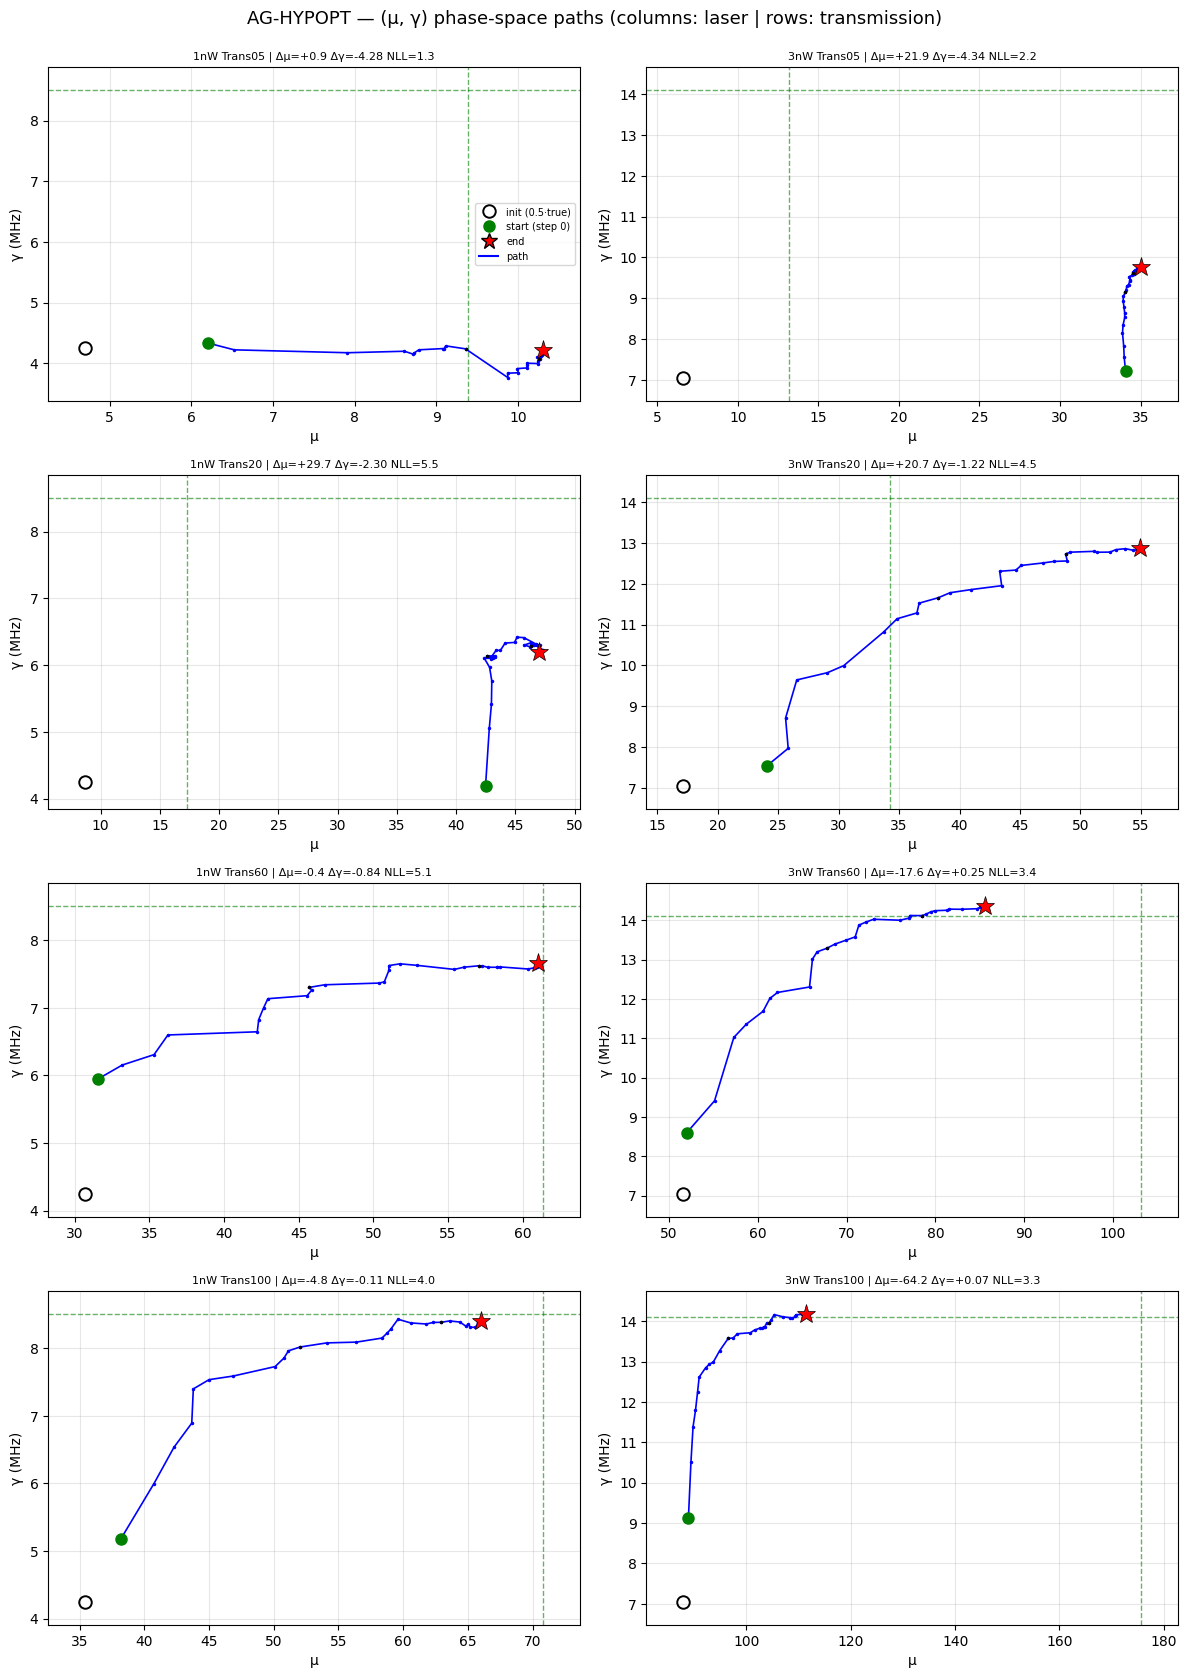

trial finished in 7.9 min
objective = 0.1188 ± 0.0835
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   10.31    +9.7 |     8.50    4.22   -50.4
1nW Trans20       17.32   47.03  +171.6 |     8.50    6.20   -27.1
1nW Trans60       61.37   61.01    -0.6 |     8.50    7.66    -9.9
1nW Trans100       70.82   66.05    -6.7 |     8.50    8.39    -1.2
3nW Trans05       13.20   35.06  +165.5 |    14.10    9.76   -30.8
3nW Trans20       34.28   54.96   +60.3 |    14.10   12.88    -8.7
3nW Trans60      103.20   85.61   -17.0 |    14.10   14.35    +1.8
3nW Trans100      175.71  111.47   -36.6 |    14.10   14.17    +0.5

weighted objective (T-graded, cap=1.0) = 0.1188 | diverged cells: 0
μ: RMSE 27.947 (rel 88.2%, bias -1.724) | γ: RMSE 2.366 (rel 23.4%, bias -1.597)


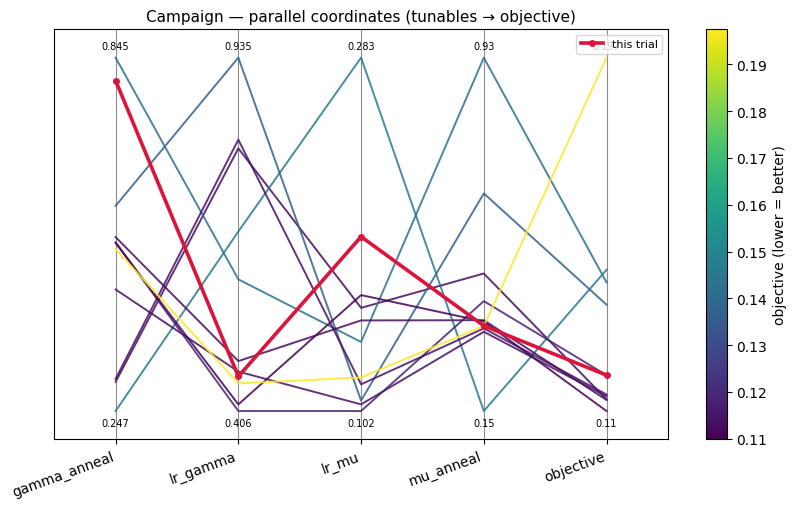

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 11 ran the highest-EI candidate (candidate 5, ei=3.79): `lr_mu=0.1915`, `mu_anneal=0.3381` (effective mu travel 0.159), `lr_gamma=0.4576`, `gamma_anneal=0.8063`. It completed in 7.9 min with objective **0.1188 +/- 0.0835** and **0 diverged cells**. Ranking: trial_08 0.1099 < trial_09 0.1126 < trial_01 0.1127 < trial_05 0.1135 < trial_07 0.1140 < **trial_11 0.1188** = trial_06 0.1188 < trial_03 < trial_04 < trial_02 < trial_10.

Aggregate accuracy: **mu rel-RMSE 88.2%** (RMSE 27.95, bias -1.72) — the worst mu of the divergence-free runs, with a much smaller |bias| than usual; **gamma rel-RMSE 23.4%** (RMSE 2.37, bias -1.60).

Per-cell relative errors:
- **mu:** 1nW T05 +9.7%, T20 **+171.6%**, T60 -0.6%, T100 -6.7% | 3nW T05 **+165.5%**, T20 +60.3%, T60 -17.0%, T100 -36.6%.
- **gamma:** 1nW T05 -50.4%, T20 -27.1%, T60 -9.9%, T100 -1.2% | 3nW T05 -30.8%, T20 -8.7%, T60 +1.8%, T100 +0.5%.

This extended mu travel past the current best (0.159 vs trial_08's 0.134) and it went **too far**: the mid/low-T mu overshoots ballooned (1nW T20 +171.6%, 3nW T05 +165.5%, 3nW T20 +60.3%) while the high-T cells improved only slightly (1nW T60 -0.6%, 1nW T100 -6.7%, 3nW T60 -17.0%). Because the mid-T cells are capped at rel-sq 1.0 and weighted (w~0.4), the extra overshoot overwhelmed the modest high-T gain and the objective fell back to 0.1188 (equal to trial_06). Together with trials 08 and 09 this brackets the optimum:

- travel 0.123 -> 0.1126 (trial_09)
- travel 0.134 -> **0.1099 (trial_08, best)**
- travel 0.159 -> 0.1188 (trial_11)

so the objective minimum lies near travel ~0.134, with the trade-off turning over between 0.134 and 0.159.

**Summary:** Trial 11 (lr_mu=0.1915, mu_anneal=0.3381, lr_gamma=0.4576, gamma_anneal=0.8063): objective 0.1188 +/- 0.0835 with 0 diverged cells; extending mu travel to 0.159 overshot the optimum - the mid/low-T mu overshoots ballooned (1nW T20 +172%, 3nW T05 +166%) and the objective fell back to trial_06's level, confirming trial_08's travel 0.134 as the best.
**Key insight:** The mu-travel optimum is now bracketed (0.123 -> 0.1126, 0.134 -> 0.1099, 0.159 -> 0.1188): the objective minimum lies near travel 0.134, beyond which extra travel costs more in mid/low-T overshoot than it gains at high T.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** The residual mid-T overshoot (1nW T20 and 3nW T05, both capped) is the main thing limiting further progress at the current optimum, and no schedule knob has reduced it without sacrificing high-T accuracy. That is the same per-regime limitation noted before (a single global mu schedule cannot fix mid-T and high-T at once); recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 11 (lr_mu=0.1915, mu_anneal=0.3381, lr_gamma=0.4576, gamma_anneal=0.8063): objective 0.1188 +/- 0.0835 with 0 diverged cells; extending mu travel to 0.159 overshot the optimum - the mid/low-T mu overshoots ballooned (1nW T20 +172%, 3nW T05 +166%) and the objective fell back to trial_06's level, confirming trial_08's travel 0.134 as the best"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The mu-travel optimum is now bracketed (0.123 -> 0.1126, 0.134 -> 0.1099, 0.159 -> 0.1188): the objective minimum lies near travel 0.134, beyond which extra travel costs more in mid/low-T overshoot than it gains at high T"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_11 | current best: trial_08


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_12.ipynb. Open it and follow its cells from the top.
